In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os
os.makedirs('XGBoost/models', exist_ok=True)

In [2]:
import pandas as pd
import joblib
import os

# ==========================================
# 📥 1. โหลดข้อมูลและตัวแปรที่คัดมาแล้ว
# ==========================================

# 1.1 ใส่ Path ข้อมูลของตัวเอง (แก้ path ให้ตรงกับเครื่องตัวเองนะคะ)
path = '/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/Data_Split/' 

# โหลดข้อมูล X_train, y_train, X_test, y_test เข้ามา
# (สมมติว่าตัวเองมีไฟล์ test แยกไว้แล้ว ถ้าไม่มีก็โหลดตัวเต็มมา split ใหม่ได้ค่ะ)
X_train_full = pd.read_csv(f'{path}X_train_90.csv')
y_train = pd.read_csv(f'{path}y_train_90.csv').squeeze() # .squeeze() เพื่อให้เป็น Series
X_test_full = pd.read_csv(f'{path}X_test_10.csv')      # ถ้าชื่อไฟล์ test ไม่ตรง แก้ได้เลยนะคะ
y_test = pd.read_csv(f'{path}y_test_10.csv').squeeze()

# -------------------------------------------------------
# 🔥 ไฮไลท์: โหลด "10 ตัวเทพ" ที่ RFE เลือกไว้มาใช้
# -------------------------------------------------------
# ต้องมั่นใจว่าไฟล์ pkl อยู่ในโฟลเดอร์ models หรือ path เดียวกัน
selected_features = joblib.load('models/rfe_lr_features.pkl')

print(f"✅ โหลดตัวแปรที่คัดเลือกมาแล้ว {len(selected_features)} ตัว:")
print(selected_features)

# 1.2 กรองข้อมูลให้เหลือแค่ 10 ตัวนี้
X_train = X_train_full[selected_features]
X_test = X_test_full[selected_features]

print("\n------------------------------------------------")
print(f"Shape ข้อมูลพร้อมเทรน:")
print(f"X_train: {X_train.shape}  <-- สังเกตว่าคอลัมน์จะเหลือแค่ 10")
print(f"X_test:  {X_test.shape}")
print("------------------------------------------------")

✅ โหลดตัวแปรที่คัดเลือกมาแล้ว 10 ตัว:
['Age', 'Gender', 'Smoking', 'BMI', 'High LDL Cholesterol', 'Stress Level', 'Sleep Hours', 'Sugar Consumption', 'Fasting Blood Sugar', 'Homocysteine Level']

------------------------------------------------
Shape ข้อมูลพร้อมเทรน:
X_train: (9000, 10)  <-- สังเกตว่าคอลัมน์จะเหลือแค่ 10
X_test:  (1000, 10)
------------------------------------------------


------------------------------
Baseline Model: XGBoost (corrected)
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [21:29:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [21:29:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [21:29:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [21:29:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [21:29:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


------------------------------
Cross-Validation Scores (Total 5 Folds):
------------------------------
Fold 1: 0.7972  (79.72%)
Fold 2: 0.7994  (79.94%)
Fold 3: 0.7983  (79.83%)
Fold 4: 0.7989  (79.89%)
Fold 5: 0.7933  (79.33%)
------------------------------
>> Average CV Accuracy: 0.7974 (± 0.0022)
------------------------------
✓ Selected best model from Fold 2
------------------------------

TEST SET PERFORMANCE (Fold 2)
Accuracy:  0.7980
Precision: 0.2500
Recall:    0.0050
F1-Score:  0.0098
ROC-AUC:   0.4970

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      1.00      0.89       800
     Disease       0.25      0.01      0.01       200

    accuracy                           0.80      1000
   macro avg       0.53      0.50      0.45      1000
weighted avg       0.69      0.80      0.71      1000



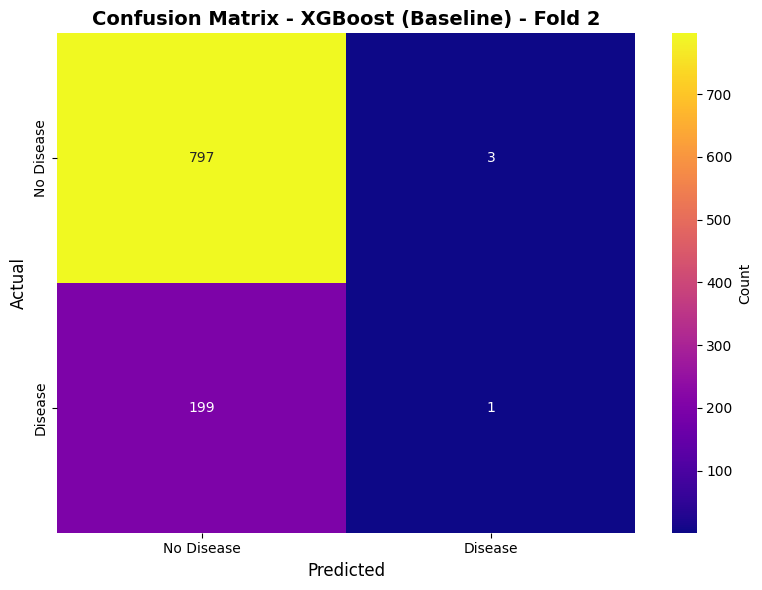


BASELINE RESULTS SUMMARY
Model               : XGBoost
Sampling            : None (Baseline)
Best_Fold           : 2
CV_Accuracy         : 0.7974
CV_Std              : 0.0022
Test_Accuracy       : 0.7980
Precision           : 0.2500
Recall              : 0.0050
F1_Score            : 0.0098
ROC_AUC             : 0.4970
✓ Saved: XGBoost/models/XGBoost_baseline_fold2.pkl


In [3]:
# Corrected: XGBoost baseline training, CV (best-fold selection), evaluation, and save
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns

print('-' * 30)
print('Baseline Model: XGBoost (corrected)')
print('-' * 30)

# Prepare arrays (handle DataFrame/Series and numpy inputs)
X_train_arr = X_train.values if hasattr(X_train, 'values') else np.array(X_train)
y_train_arr = y_train.values.ravel() if hasattr(y_train, 'values') else np.array(y_train).ravel()
X_test_arr  = X_test.values if hasattr(X_test, 'values') else np.array(X_test)
y_test_arr  = y_test.values.ravel() if hasattr(y_test, 'values') else np.array(y_test).ravel()

# Cross-validation with best-fold selection
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
best_model_xgb_baseline = None
best_score_xgb_baseline = -1.0
best_fold_idx_xgb_baseline = -1

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_arr, y_train_arr)):
    X_train_fold, X_val_fold = X_train_arr[train_idx], X_train_arr[val_idx]
    y_train_fold, y_val_fold = y_train_arr[train_idx], y_train_arr[val_idx]

    xgb_fold = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    xgb_fold.fit(X_train_fold, y_train_fold)

    score = xgb_fold.score(X_val_fold, y_val_fold)
    cv_scores.append(score)

    if score > best_score_xgb_baseline:
        best_model_xgb_baseline = xgb_fold
        best_score_xgb_baseline = score
        best_fold_idx_xgb_baseline = fold + 1

print('-' * 30)
print(f'Cross-Validation Scores (Total {len(cv_scores)} Folds):')
print('-' * 30)
for i, score in enumerate(cv_scores):
    print(f'Fold {i+1}: {score:.4f}  ({score*100:.2f}%)')
print('-' * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print('-' * 30)

print(f'✓ Selected best model from Fold {best_fold_idx_xgb_baseline}')
print('-' * 30)

# Predictions using best-fold model
y_pred = best_model_xgb_baseline.predict(X_test_arr)
if hasattr(best_model_xgb_baseline, 'predict_proba'):
    y_pred_proba = best_model_xgb_baseline.predict_proba(X_test_arr)[:, 1]
else:
    y_pred_proba = best_model_xgb_baseline.decision_function(X_test_arr)

# Compute test metrics
test_accuracy = accuracy_score(y_test_arr, y_pred)
test_precision = precision_score(y_test_arr, y_pred, zero_division=0)
test_recall = recall_score(y_test_arr, y_pred, zero_division=0)
test_f1 = f1_score(y_test_arr, y_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test_arr, y_pred_proba)

print('\n' + '=' * 50)
print('TEST SET PERFORMANCE (Fold {})'.format(best_fold_idx_xgb_baseline))
print('=' * 50)
print(f'Accuracy:  {test_accuracy:.4f}')
print(f'Precision: {test_precision:.4f}')
print(f'Recall:    {test_recall:.4f}')
print(f'F1-Score:  {test_f1:.4f}')
print(f'ROC-AUC:   {test_roc_auc:.4f}')
print('=' * 50)

print('\nClassification Report:')
print(classification_report(y_test_arr, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_arr, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='plasma', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - XGBoost (Baseline) - Fold {}'.format(best_fold_idx_xgb_baseline), fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
xgb_baseline_results = {
    'Model': 'XGBoost',
    'Sampling': 'None (Baseline)',
    'Best_Fold': best_fold_idx_xgb_baseline,
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc
}

print('\n' + '=' * 50)
print('BASELINE RESULTS SUMMARY')
print('=' * 50)
for key, value in xgb_baseline_results.items():
    if isinstance(value, float):
        print(f'{key:20s}: {value:.4f}')
    else:
        print(f'{key:20s}: {value}')
print('=' * 50)

# Ensure save directory exists and save model
os.makedirs('XGBoost/models', exist_ok=True)
model_path = f'XGBoost/models/XGBoost_baseline_fold{best_fold_idx_xgb_baseline}.pkl'
joblib.dump(best_model_xgb_baseline, model_path)
print(f'✓ Saved: {model_path}')

------------------------------
XGBoost + SMOTE
------------------------------
Original training set size: 9000
After SMOTE training set size: 14400
Original class distribution: {0: np.int64(7200), 1: np.int64(1800)}
After SMOTE class distribution: {0: np.int64(7200), 1: np.int64(7200)}
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


------------------------------
Cross-Validation Scores (Total 5 Folds):
------------------------------
Fold 1: 0.7150  (71.50%)
Fold 2: 0.7428  (74.28%)
Fold 3: 0.7172  (71.72%)
Fold 4: 0.7322  (73.22%)
Fold 5: 0.7367  (73.67%)
------------------------------
>> Average CV Accuracy: 0.7288 (± 0.0109)
------------------------------
✓ Selected best model from Fold 2
------------------------------

TEST SET PERFORMANCE (SMOTE) - Fold 2
Accuracy:  0.7490
Precision: 0.2960
Recall:    0.1850
F1-Score:  0.2277
ROC-AUC:   0.5480

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.81      0.89      0.85       800
     Disease       0.30      0.18      0.23       200

    accuracy                           0.75      1000
   macro avg       0.55      0.54      0.54      1000
weighted avg       0.71      0.75      0.73      1000



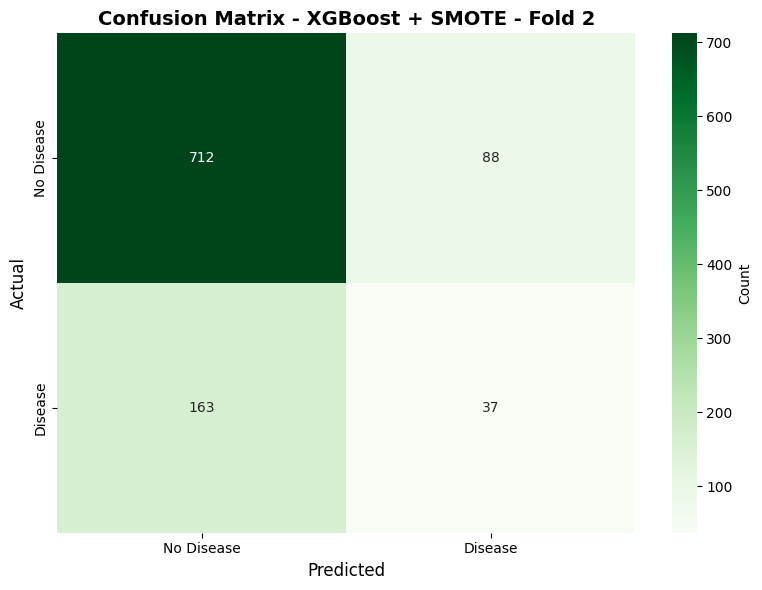


SMOTE RESULTS SUMMARY
Model               : XGBoost
Sampling            : SMOTE
Best_Fold           : 2
CV_Accuracy         : 0.7288
CV_Std              : 0.0109
Test_Accuracy       : 0.7490
Precision           : 0.2960
Recall              : 0.1850
F1_Score            : 0.2277
ROC_AUC             : 0.5480
✓ Saved: XGBoost/models/XGBoost_smote_fold2.pkl
✓ Saved: XGBoost/models/smote_sampler_xgb.pkl


In [4]:
from imblearn.over_sampling import SMOTE

print("-" * 30)
print('XGBoost + SMOTE')
print("-" * 30)

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train.values.ravel())

print(f"Original training set size: {len(X_train)}")
print(f"After SMOTE training set size: {len(X_train_smote)}")
print(f"Original class distribution: {dict(pd.Series(y_train.values.ravel()).value_counts())}")
print(f"After SMOTE class distribution: {dict(pd.Series(y_train_smote).value_counts())}")
print("-" * 30)

# Cross-validation with SMOTE and best-fold selection
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
best_model_xgb_smote = None
best_score_xgb_smote = -1.0
best_fold_idx_xgb_smote = -1

X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
y_train_np = y_train.values.ravel() if hasattr(y_train, 'values') else y_train

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_np, y_train_np)):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train_np[train_idx], y_train_np[val_idx]
    
    try:
        X_train_fold_smote, y_train_fold_smote = smote.fit_resample(X_train_fold, y_train_fold)
        
        xgb_fold = XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            eval_metric='logloss'
        )
        xgb_fold.fit(X_train_fold_smote, y_train_fold_smote)
        score = xgb_fold.score(X_val_fold, y_val_fold)
        cv_scores.append(score)
        
        # Track best fold
        if score > best_score_xgb_smote:
            best_model_xgb_smote = xgb_fold
            best_score_xgb_smote = score
            best_fold_idx_xgb_smote = fold + 1
    except ValueError as e:
        print(f"Warning in fold: {e}")
        continue

print("-" * 30)
print(f"Cross-Validation Scores (Total {len(cv_scores)} Folds):")
print("-" * 30)
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}  ({score*100:.2f}%)")
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Use best fold model for test evaluation
print(f"✓ Selected best model from Fold {best_fold_idx_xgb_smote}")
print("-" * 30)

X_test_np = X_test.values if hasattr(X_test, 'values') else X_test

# Predictions using best-fold model
y_pred = best_model_xgb_smote.predict(X_test_np)
y_pred_proba = best_model_xgb_smote.predict_proba(X_test_np)[:, 1]

# Test set performance
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (SMOTE) - Fold {}".format(best_fold_idx_xgb_smote))
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - XGBoost + SMOTE - Fold {}'.format(best_fold_idx_xgb_smote), fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
xgb_smote_results = {
    'Model': 'XGBoost',
    'Sampling': 'SMOTE',
    'Best_Fold': best_fold_idx_xgb_smote,
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc
}

print("\n" + "=" * 50)
print("SMOTE RESULTS SUMMARY")
print("=" * 50)
for key, value in xgb_smote_results.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.4f}")
    else:
        print(f"{key:20s}: {value}")
print("=" * 50)

# Save best fold model and sampler
joblib.dump(best_model_xgb_smote, 'XGBoost/models/XGBoost_smote_fold{}.pkl'.format(best_fold_idx_xgb_smote))
joblib.dump(smote, 'XGBoost/models/smote_sampler_xgb.pkl')
print("✓ Saved: XGBoost/models/XGBoost_smote_fold{}.pkl".format(best_fold_idx_xgb_smote))
print("✓ Saved: XGBoost/models/smote_sampler_xgb.pkl")

------------------------------
XGBoost + ADASYN
------------------------------


Original training set size: 9000
After ADASYN training set size: 14431
Original class distribution: {0: np.int64(7200), 1: np.int64(1800)}
After ADASYN class distribution: {1: np.int64(7231), 0: np.int64(7200)}
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


------------------------------
Cross-Validation Scores (Total 5 Folds):
------------------------------
Fold 1: 0.7361  (73.61%)
Fold 2: 0.7489  (74.89%)
Fold 3: 0.7422  (74.22%)
Fold 4: 0.7489  (74.89%)
Fold 5: 0.7472  (74.72%)
------------------------------
>> Average CV Accuracy: 0.7447 (± 0.0049)
------------------------------
✓ Selected best model from Fold 2
------------------------------

TEST SET PERFORMANCE (ADASYN) - Fold 2
Accuracy:  0.7370
Precision: 0.2212
Recall:    0.1250
F1-Score:  0.1597
ROC-AUC:   0.5350

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.89      0.84       800
     Disease       0.22      0.12      0.16       200

    accuracy                           0.74      1000
   macro avg       0.51      0.51      0.50      1000
weighted avg       0.69      0.74      0.71      1000



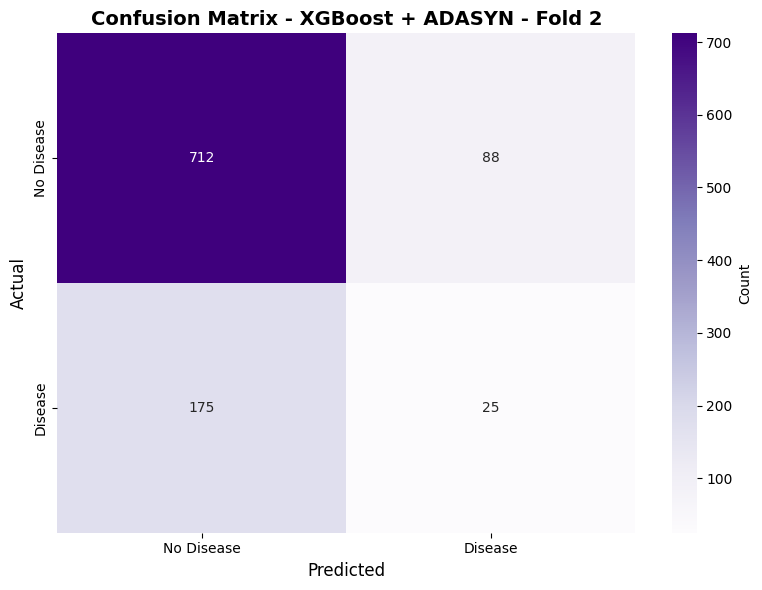


ADASYN RESULTS SUMMARY
Model               : XGBoost
Sampling            : ADASYN
Best_Fold           : 2
CV_Accuracy         : 0.7447
CV_Std              : 0.0049
Test_Accuracy       : 0.7370
Precision           : 0.2212
Recall              : 0.1250
F1_Score            : 0.1597
ROC_AUC             : 0.5350
✓ Saved: XGBoost/models/XGBoost_adasyn_fold2.pkl
✓ Saved: XGBoost/models/adasyn_sampler_xgb.pkl


In [5]:
from imblearn.over_sampling import ADASYN

print("-" * 30)
print('XGBoost + ADASYN')
print("-" * 30)

# Initialize ADASYN
adasyn = ADASYN(random_state=42, n_neighbors=5)

# Apply ADASYN to training data
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train.values.ravel())

print(f"Original training set size: {len(X_train)}")
print(f"After ADASYN training set size: {len(X_train_adasyn)}")
print(f"Original class distribution: {dict(pd.Series(y_train.values.ravel()).value_counts())}")
print(f"After ADASYN class distribution: {dict(pd.Series(y_train_adasyn).value_counts())}")
print("-" * 30)

# Cross-validation with ADASYN and best-fold selection
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
best_model_xgb_adasyn = None
best_score_xgb_adasyn = -1.0
best_fold_idx_xgb_adasyn = -1

X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
y_train_np = y_train.values.ravel() if hasattr(y_train, 'values') else y_train

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_np, y_train_np)):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train_np[train_idx], y_train_np[val_idx]
    
    try:
        X_train_fold_adasyn, y_train_fold_adasyn = adasyn.fit_resample(X_train_fold, y_train_fold)
        
        xgb_fold = XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            eval_metric='logloss'
        )
        xgb_fold.fit(X_train_fold_adasyn, y_train_fold_adasyn)
        score = xgb_fold.score(X_val_fold, y_val_fold)
        cv_scores.append(score)
        
        # Track best fold
        if score > best_score_xgb_adasyn:
            best_model_xgb_adasyn = xgb_fold
            best_score_xgb_adasyn = score
            best_fold_idx_xgb_adasyn = fold + 1
    except ValueError as e:
        print(f"Warning in fold: {e}")
        continue

print("-" * 30)
print(f"Cross-Validation Scores (Total {len(cv_scores)} Folds):")
print("-" * 30)
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}  ({score*100:.2f}%)")
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Use best fold model for test evaluation
print(f"✓ Selected best model from Fold {best_fold_idx_xgb_adasyn}")
print("-" * 30)

X_test_np = X_test.values if hasattr(X_test, 'values') else X_test

# Predictions using best-fold model
y_pred = best_model_xgb_adasyn.predict(X_test_np)
y_pred_proba = best_model_xgb_adasyn.predict_proba(X_test_np)[:, 1]

# Test set performance
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (ADASYN) - Fold {}".format(best_fold_idx_xgb_adasyn))
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - XGBoost + ADASYN - Fold {}'.format(best_fold_idx_xgb_adasyn), fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
xgb_adasyn_results = {
    'Model': 'XGBoost',
    'Sampling': 'ADASYN',
    'Best_Fold': best_fold_idx_xgb_adasyn,
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc
}

print("\n" + "=" * 50)
print("ADASYN RESULTS SUMMARY")
print("=" * 50)
for key, value in xgb_adasyn_results.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.4f}")
    else:
        print(f"{key:20s}: {value}")
print("=" * 50)

# Save best fold model and sampler
joblib.dump(best_model_xgb_adasyn, 'XGBoost/models/XGBoost_adasyn_fold{}.pkl'.format(best_fold_idx_xgb_adasyn))
joblib.dump(adasyn, 'XGBoost/models/adasyn_sampler_xgb.pkl')
print("✓ Saved: XGBoost/models/XGBoost_adasyn_fold{}.pkl".format(best_fold_idx_xgb_adasyn))
print("✓ Saved: XGBoost/models/adasyn_sampler_xgb.pkl")

------------------------------
XGBoost + RandomUnderSampler
------------------------------
Original training set size: 9000
After RUS training set size: 3600
Original class distribution: {0: np.int64(7200), 1: np.int64(1800)}
After RUS class distribution: {0: np.int64(1800), 1: np.int64(1800)}
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


------------------------------
Cross-Validation Scores (Total 5 Folds):
------------------------------
Fold 1: 0.5094  (50.94%)
Fold 2: 0.5133  (51.33%)
Fold 3: 0.4839  (48.39%)
Fold 4: 0.4989  (49.89%)
Fold 5: 0.5111  (51.11%)
------------------------------
>> Average CV Accuracy: 0.5033 (± 0.0109)
------------------------------
✓ Selected best model from Fold 2
------------------------------

TEST SET PERFORMANCE (RUS) - Fold 2
Accuracy:  0.4860
Precision: 0.1981
Recall:    0.5150
F1-Score:  0.2861
ROC-AUC:   0.4872

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.48      0.60       800
     Disease       0.20      0.52      0.29       200

    accuracy                           0.49      1000
   macro avg       0.50      0.50      0.44      1000
weighted avg       0.68      0.49      0.54      1000



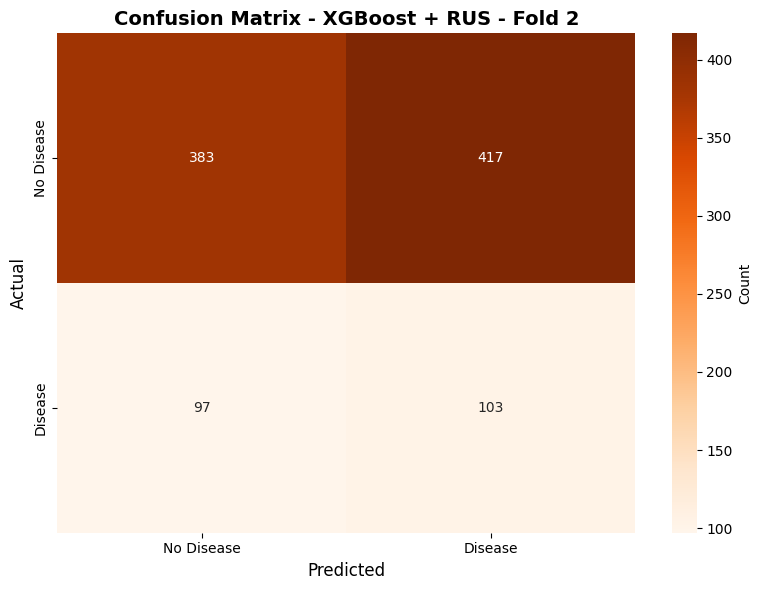


RUS RESULTS SUMMARY
Model               : XGBoost
Sampling            : RandomUnderSampler
Best_Fold           : 2
CV_Accuracy         : 0.5033
CV_Std              : 0.0109
Test_Accuracy       : 0.4860
Precision           : 0.1981
Recall              : 0.5150
F1_Score            : 0.2861
ROC_AUC             : 0.4872
✓ Saved: XGBoost/models/XGBoost_rus_fold2.pkl
✓ Saved: XGBoost/models/rus_sampler_xgb.pkl


In [6]:
from imblearn.under_sampling import RandomUnderSampler

print("-" * 30)
print('XGBoost + RandomUnderSampler')
print("-" * 30)

# Initialize RUS
rus = RandomUnderSampler(random_state=42)

# Apply RUS to training data
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train.values.ravel())

print(f"Original training set size: {len(X_train)}")
print(f"After RUS training set size: {len(X_train_rus)}")
print(f"Original class distribution: {dict(pd.Series(y_train.values.ravel()).value_counts())}")
print(f"After RUS class distribution: {dict(pd.Series(y_train_rus).value_counts())}")
print("-" * 30)

# Cross-validation with RUS and best-fold selection
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
best_model_xgb_rus = None
best_score_xgb_rus = -1.0
best_fold_idx_xgb_rus = -1

X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
y_train_np = y_train.values.ravel() if hasattr(y_train, 'values') else y_train

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_np, y_train_np)):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train_np[train_idx], y_train_np[val_idx]
    
    X_train_fold_rus, y_train_fold_rus = rus.fit_resample(X_train_fold, y_train_fold)
    
    xgb_fold = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric='logloss'
    )
    xgb_fold.fit(X_train_fold_rus, y_train_fold_rus)
    score = xgb_fold.score(X_val_fold, y_val_fold)
    cv_scores.append(score)
    
    # Track best fold
    if score > best_score_xgb_rus:
        best_model_xgb_rus = xgb_fold
        best_score_xgb_rus = score
        best_fold_idx_xgb_rus = fold + 1

print("-" * 30)
print(f"Cross-Validation Scores (Total {len(cv_scores)} Folds):")
print("-" * 30)
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}  ({score*100:.2f}%)")
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Use best fold model for test evaluation
print(f"✓ Selected best model from Fold {best_fold_idx_xgb_rus}")
print("-" * 30)

X_test_np = X_test.values if hasattr(X_test, 'values') else X_test

# Predictions using best-fold model
y_pred = best_model_xgb_rus.predict(X_test_np)
y_pred_proba = best_model_xgb_rus.predict_proba(X_test_np)[:, 1]

# Test set performance
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (RUS) - Fold {}".format(best_fold_idx_xgb_rus))
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - XGBoost + RUS - Fold {}'.format(best_fold_idx_xgb_rus), fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
xgb_rus_results = {
    'Model': 'XGBoost',
    'Sampling': 'RandomUnderSampler',
    'Best_Fold': best_fold_idx_xgb_rus,
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc
}

print("\n" + "=" * 50)
print("RUS RESULTS SUMMARY")
print("=" * 50)
for key, value in xgb_rus_results.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.4f}")
    else:
        print(f"{key:20s}: {value}")
print("=" * 50)

# Save best fold model and sampler
joblib.dump(best_model_xgb_rus, 'XGBoost/models/XGBoost_rus_fold{}.pkl'.format(best_fold_idx_xgb_rus))
joblib.dump(rus, 'XGBoost/models/rus_sampler_xgb.pkl')
print("✓ Saved: XGBoost/models/XGBoost_rus_fold{}.pkl".format(best_fold_idx_xgb_rus))
print("✓ Saved: XGBoost/models/rus_sampler_xgb.pkl")

------------------------------
XGBoost + NearMiss
------------------------------
Original training set size: 9000
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [21:29:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 1: 0.3756


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [21:29:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


...

Fold 3: 0.3672


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [21:29:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Fold 4: 0.3644


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [21:29:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fold 5: 0.3661
------------------------------
Cross-Validation Scores (Total 5 Folds):
------------------------------
Fold 1: 0.3756  (37.56%)
Fold 2: 0.3739  (37.39%)
Fold 3: 0.3672  (36.72%)
Fold 4: 0.3644  (36.44%)
Fold 5: 0.3661  (36.61%)
------------------------------
>> Average CV Accuracy: 0.3694 (± 0.0044)
------------------------------
✓ Selected best model from Fold 1
------------------------------

TEST SET PERFORMANCE (NearMiss) - Fold 1
Accuracy:  0.3870
Precision: 0.2112
Recall:    0.7550
F1-Score:  0.3301
ROC-AUC:   0.5131


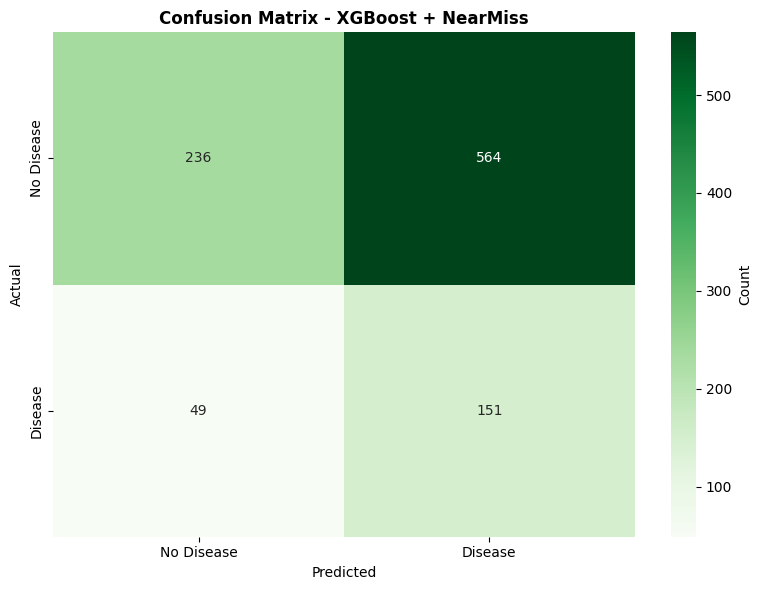

✓ Saved: XGBoost/models/XGBoost_nearmiss_fold1.pkl
✓ Saved: XGBoost/models/nearmiss_sampler_xgb.pkl
✓ Saved model


In [7]:
from imblearn.under_sampling import NearMiss
from xgboost import XGBClassifier

print("-" * 30)
print('XGBoost + NearMiss')
print("-" * 30)

# Prepare arrays
X_train_arr = X_train.values if hasattr(X_train, 'values') else np.array(X_train)
y_train_arr = y_train.values.ravel() if hasattr(y_train, 'values') else np.array(y_train).ravel()
X_test_arr = X_test.values if hasattr(X_test, 'values') else np.array(X_test)
y_test_arr = y_test.values.ravel() if hasattr(y_test, 'values') else np.array(y_test).ravel()

# 1. Initialize NearMiss sampler
nm = NearMiss(version=2)

print(f"Original training set size: {len(X_train_arr)}")
print("-" * 30)

# 2. Cross-validation with NearMiss (resample only training folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
best_model_xgb_nearmiss = None
best_score_xgb_nearmiss = -1.0
best_fold_idx_xgb_nearmiss = -1

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_arr, y_train_arr)):
    X_train_fold, X_val_fold = X_train_arr[train_idx], X_train_arr[val_idx]
    y_train_fold, y_val_fold = y_train_arr[train_idx], y_train_arr[val_idx]

    try:
        X_train_fold_nearmiss, y_train_fold_nearmiss = nm.fit_resample(X_train_fold, y_train_fold)

        xgb_fold = XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            use_label_encoder=False,
            eval_metric='logloss'
        )
        xgb_fold.fit(X_train_fold_nearmiss, y_train_fold_nearmiss)

        score = xgb_fold.score(X_val_fold, y_val_fold)
        cv_scores.append(score)
        print(f"Fold {fold+1}: {score:.4f}")

        if score > best_score_xgb_nearmiss:
            best_model_xgb_nearmiss = xgb_fold
            best_score_xgb_nearmiss = score
            best_fold_idx_xgb_nearmiss = fold + 1
    except ValueError as e:
        print(f"Warning in fold {fold+1}: {e}")
        continue

if len(cv_scores) == 0:
    raise RuntimeError('No successful CV folds for NearMiss; check class distribution and parameters')

print("-" * 30)
print(f"Cross-Validation Scores (Total {len(cv_scores)} Folds):")
print("-" * 30)
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}  ({score*100:.2f}%)")
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Use best fold model for test evaluation
print(f"✓ Selected best model from Fold {best_fold_idx_xgb_nearmiss}")
print("-" * 30)

# Predictions using best-fold model
y_pred = best_model_xgb_nearmiss.predict(X_test_arr)
if hasattr(best_model_xgb_nearmiss, 'predict_proba'):
    y_pred_proba = best_model_xgb_nearmiss.predict_proba(X_test_arr)[:, 1]
else:
    y_pred_proba = best_model_xgb_nearmiss.decision_function(X_test_arr)

# Test set performance
test_accuracy = accuracy_score(y_test_arr, y_pred)
test_precision = precision_score(y_test_arr, y_pred, zero_division=0)
test_recall = recall_score(y_test_arr, y_pred, zero_division=0)
test_f1 = f1_score(y_test_arr, y_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test_arr, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (NearMiss) - Fold {}".format(best_fold_idx_xgb_nearmiss))
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_arr, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost + NearMiss', fontweight='bold')
plt.tight_layout()
plt.show()

# Save Results
xgb_nearmiss_results = {
    'Model': 'XGBoost',
    'Sampling': 'NearMiss',
    'Best_Fold': best_fold_idx_xgb_nearmiss,
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc
}

os.makedirs('XGBoost/models', exist_ok=True)
joblib.dump(best_model_xgb_nearmiss, 'XGBoost/models/XGBoost_nearmiss_fold{}.pkl'.format(best_fold_idx_xgb_nearmiss))
joblib.dump(nm, 'XGBoost/models/nearmiss_sampler_xgb.pkl')
print("✓ Saved: XGBoost/models/XGBoost_nearmiss_fold{}.pkl".format(best_fold_idx_xgb_nearmiss))
print("✓ Saved: XGBoost/models/nearmiss_sampler_xgb.pkl")
print("✓ Saved model")

------------------------------
XGBoost + Cluster Centroids
------------------------------
Resampling... (This may take a while ⏳)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Original size: 9000
After CC size: 3600
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [21:29:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


------------------------------
Cross-Validation Scores (Total 5 Folds):
------------------------------
Fold 1: 0.3617  (36.17%)
Fold 2: 0.3533  (35.33%)
Fold 3: 0.3222  (32.22%)
Fold 4: 0.3383  (33.83%)
Fold 5: 0.3311  (33.11%)
------------------------------
>> Average CV Accuracy: 0.3413 (± 0.0144)
------------------------------
TEST SET PERFORMANCE (Cluster Centroids) - Fold 1
Accuracy:  0.3500
Precision: 0.2008
Recall:    0.7550
F1-Score:  0.3172
ROC-AUC:   0.5026


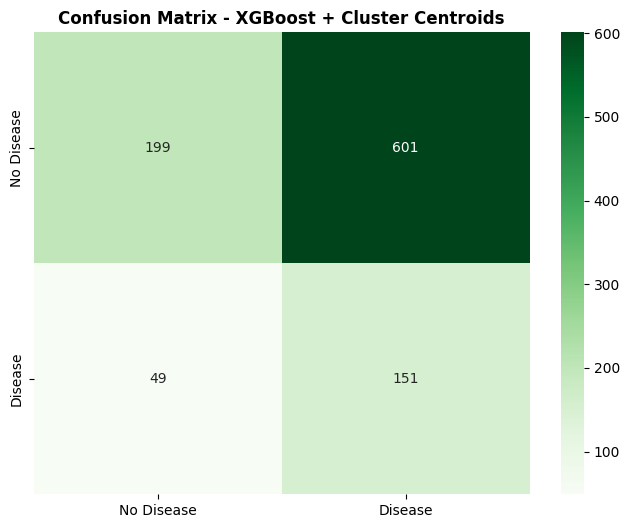

✓ Saved: XGBoost/models/XGBoost_cc_fold1.pkl
✓ Saved: XGBoost/models/cc_sampler_xgb.pkl
✓ Saved model


In [8]:
from imblearn.under_sampling import ClusterCentroids

print("-" * 30)
print('XGBoost + Cluster Centroids')
print("-" * 30)

# 1. Apply Cluster Centroids
cc = ClusterCentroids(random_state=42, voting='soft')
print("Resampling... (This may take a while ⏳)")
X_train_cc, y_train_cc = cc.fit_resample(X_train, y_train.values.ravel())

print(f"Original size: {len(X_train)}")
print(f"After CC size: {len(X_train_cc)}")
print("-" * 30)

# 2. Train Model
xgb_cc = XGBClassifier(
    n_estimators=100, random_state=42,
    use_label_encoder=False, eval_metric='logloss'
)
xgb_cc.fit(X_train_cc, y_train_cc)

# 3. Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
best_model_xgb_cc = None
best_score_xgb_cc = -1.0
best_fold_idx_xgb_cc = -1

X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
y_train_np = y_train.values.ravel() if hasattr(y_train, 'values') else y_train

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_np, y_train_np)):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train_np[train_idx], y_train_np[val_idx]

    try:
        # Apply Cluster Centroids to each fold's training subset
        X_train_fold_cc, y_train_fold_cc = cc.fit_resample(X_train_fold, y_train_fold)

        xgb_fold = XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            eval_metric='logloss'
        )
        xgb_fold.fit(X_train_fold_cc, y_train_fold_cc)
        score = xgb_fold.score(X_val_fold, y_val_fold)
        cv_scores.append(score)

        # Track the best model and score based on cross-validation
        if score > best_score_xgb_cc:
            best_model_xgb_cc = xgb_fold
            best_score_xgb_cc = score
            best_fold_idx_xgb_cc = fold + 1
    except ValueError as e:
        print(f"Warning in fold: {e}")
        continue

print("-" * 30)
print(f"Cross-Validation Scores (Total {len(cv_scores)} Folds):")
print("-" * 30)
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}  ({score*100:.2f}%)")
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Predictions using best model
X_test_np = X_test.values if hasattr(X_test, 'values') else X_test
y_pred = best_model_xgb_cc.predict(X_test_np)
y_pred_proba = best_model_xgb_cc.predict_proba(X_test_np)[:, 1]

# Evaluation Metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=" * 50)
print(f"TEST SET PERFORMANCE (Cluster Centroids) - Fold {best_fold_idx_xgb_cc}")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - XGBoost + Cluster Centroids', fontweight='bold')
plt.show()

# Save Results
xgb_cc_results = {
    'Model': 'XGBoost', 'Sampling': 'ClusterCentroids',
    'Best_Fold': best_fold_idx_xgb_cc,
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy, 'Precision': test_precision,
    'Recall': test_recall, 'F1_Score': test_f1, 'ROC_AUC': test_roc_auc
}

joblib.dump(xgb_cc, 'XGBoost/models/XGB_cluster_centroids.pkl')
joblib.dump(best_model_xgb_cc, 'XGBoost/models/XGBoost_cc_fold{}.pkl'.format(best_fold_idx_xgb_cc))
joblib.dump(cc, 'XGBoost/models/cc_sampler_xgb.pkl')
print("✓ Saved: XGBoost/models/XGBoost_cc_fold{}.pkl".format(best_fold_idx_xgb_cc))
print("✓ Saved: XGBoost/models/cc_sampler_xgb.pkl")
print("✓ Saved model")

------------------------------
XGBoost + SMOTETomek
------------------------------


Original training set size: 9000
After SMOTETomek training set size: 14162
Original class distribution: {0: np.int64(7200), 1: np.int64(1800)}
After SMOTETomek class distribution: {0: np.int64(7081), 1: np.int64(7081)}
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

------------------------------
Cross-Validation Scores (Total 5 Folds):
------------------------------
Fold 1: 0.7306  (73.06%)
Fold 2: 0.7350  (73.50%)
Fold 3: 0.7167  (71.67%)
Fold 4: 0.7311  (73.11%)
Fold 5: 0.7417  (74.17%)
------------------------------
>> Average CV Accuracy: 0.7310 (± 0.0082)
------------------------------
✓ Selected best model from Fold 5
------------------------------

TEST SET PERFORMANCE (SMOTETomek) - Fold 5
Accuracy:  0.7320
Precision: 0.2302
Recall:    0.1450
F1-Score:  0.1779
ROC-AUC:   0.5143

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.88      0.84       800
     Disease       0.23      0.14      0.18       200

    accuracy                           0.73      1000
   macro avg       0.52      0.51      0.51      1000
weighted avg       0.69      0.73      0.71      1000



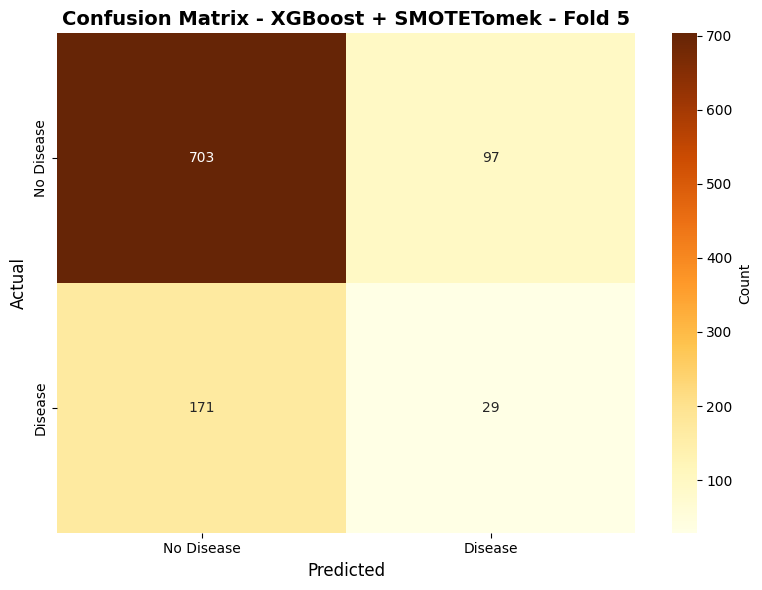


SMOTETomek RESULTS SUMMARY
Model               : XGBoost
Sampling            : SMOTETomek
Best_Fold           : 5
CV_Accuracy         : 0.7310
CV_Std              : 0.0082
Test_Accuracy       : 0.7320
Precision           : 0.2302
Recall              : 0.1450
F1_Score            : 0.1779
ROC_AUC             : 0.5143
✓ Saved: XGBoost/models/XGBoost_smote_tomek_fold5.pkl
✓ Saved: XGBoost/models/smote_tomek_sampler_xgb.pkl


In [9]:
from imblearn.combine import SMOTETomek

print("-" * 30)
print('XGBoost + SMOTETomek')
print("-" * 30)

# Initialize SMOTETomek
smote_tomek = SMOTETomek(random_state=42)

# Apply SMOTETomek to training data
X_train_smote_tomek, y_train_smote_tomek = smote_tomek.fit_resample(X_train, y_train.values.ravel())

print(f"Original training set size: {len(X_train)}")
print(f"After SMOTETomek training set size: {len(X_train_smote_tomek)}")
print(f"Original class distribution: {dict(pd.Series(y_train.values.ravel()).value_counts())}")
print(f"After SMOTETomek class distribution: {dict(pd.Series(y_train_smote_tomek).value_counts())}")
print("-" * 30)

# Cross-validation with SMOTETomek and best-fold selection
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
best_model_xgb_smote_tomek = None
best_score_xgb_smote_tomek = -1.0
best_fold_idx_xgb_smote_tomek = -1

X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
y_train_np = y_train.values.ravel() if hasattr(y_train, 'values') else y_train

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_np, y_train_np)):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train_np[train_idx], y_train_np[val_idx]
    
    try:
        X_train_fold_smote_tomek, y_train_fold_smote_tomek = smote_tomek.fit_resample(X_train_fold, y_train_fold)
        
        xgb_fold = XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            eval_metric='logloss'
        )
        xgb_fold.fit(X_train_fold_smote_tomek, y_train_fold_smote_tomek)
        score = xgb_fold.score(X_val_fold, y_val_fold)
        cv_scores.append(score)
        
        # Track best fold
        if score > best_score_xgb_smote_tomek:
            best_model_xgb_smote_tomek = xgb_fold
            best_score_xgb_smote_tomek = score
            best_fold_idx_xgb_smote_tomek = fold + 1
    except ValueError as e:
        print(f"Warning in fold: {e}")
        continue

print("-" * 30)
print(f"Cross-Validation Scores (Total {len(cv_scores)} Folds):")
print("-" * 30)
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}  ({score*100:.2f}%)")
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Use best fold model for test evaluation
print(f"✓ Selected best model from Fold {best_fold_idx_xgb_smote_tomek}")
print("-" * 30)

X_test_np = X_test.values if hasattr(X_test, 'values') else X_test

# Predictions using best-fold model
y_pred = best_model_xgb_smote_tomek.predict(X_test_np)
y_pred_proba = best_model_xgb_smote_tomek.predict_proba(X_test_np)[:, 1]

# Test set performance
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (SMOTETomek) - Fold {}".format(best_fold_idx_xgb_smote_tomek))
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlOrBr', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - XGBoost + SMOTETomek - Fold {}'.format(best_fold_idx_xgb_smote_tomek), fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
xgb_smote_tomek_results = {
    'Model': 'XGBoost',
    'Sampling': 'SMOTETomek',
    'Best_Fold': best_fold_idx_xgb_smote_tomek,
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc
}

print("\n" + "=" * 50)
print("SMOTETomek RESULTS SUMMARY")
print("=" * 50)
for key, value in xgb_smote_tomek_results.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.4f}")
    else:
        print(f"{key:20s}: {value}")
print("=" * 50)

# Save best fold model and sampler
joblib.dump(best_model_xgb_smote_tomek, 'XGBoost/models/XGBoost_smote_tomek_fold{}.pkl'.format(best_fold_idx_xgb_smote_tomek))
joblib.dump(smote_tomek, 'XGBoost/models/smote_tomek_sampler_xgb.pkl')
print("✓ Saved: XGBoost/models/XGBoost_smote_tomek_fold{}.pkl".format(best_fold_idx_xgb_smote_tomek))
print("✓ Saved: XGBoost/models/smote_tomek_sampler_xgb.pkl")

------------------------------
XGBoost + SMOTEENN
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Original training set size: 9000
After SMOTEENN training set size: 8907
Original class distribution: {0: np.int64(7200), 1: np.int64(1800)}
After SMOTEENN class distribution: {1: np.int64(5911), 0: np.int64(2996)}
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

------------------------------
Cross-Validation Scores (Total 5 Folds):
------------------------------
Fold 1: 0.4878  (48.78%)
Fold 2: 0.5122  (51.22%)
Fold 3: 0.4967  (49.67%)
Fold 4: 0.5167  (51.67%)
Fold 5: 0.5156  (51.56%)
------------------------------
>> Average CV Accuracy: 0.5058 (± 0.0115)
------------------------------
✓ Selected best model from Fold 4
------------------------------

TEST SET PERFORMANCE (SMOTEENN) - Fold 4
Accuracy:  0.5080
Precision: 0.2115
Recall:    0.5350
F1-Score:  0.3031
ROC-AUC:   0.5235

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.81      0.50      0.62       800
     Disease       0.21      0.54      0.30       200

    accuracy                           0.51      1000
   macro avg       0.51      0.52      0.46      1000
weighted avg       0.69      0.51      0.56      1000



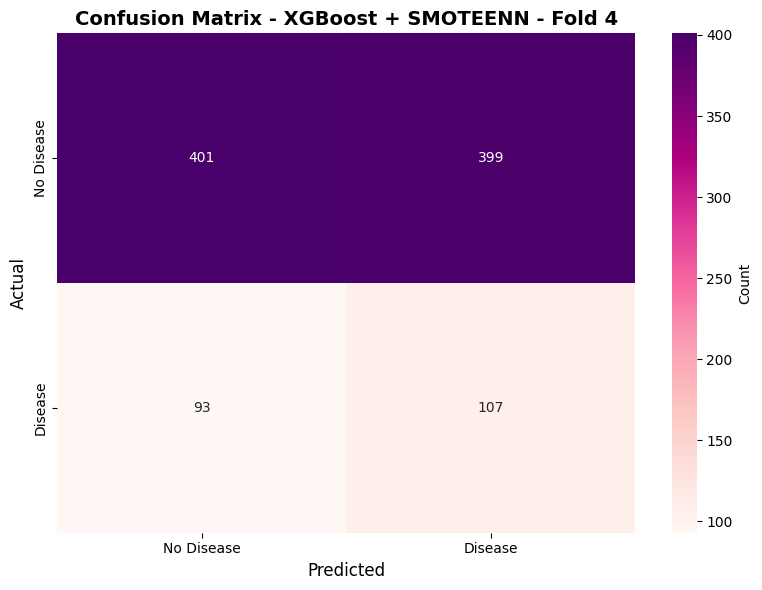


SMOTEENN RESULTS SUMMARY
Model               : XGBoost
Sampling            : SMOTEENN
Best_Fold           : 4
CV_Accuracy         : 0.5058
CV_Std              : 0.0115
Test_Accuracy       : 0.5080
Precision           : 0.2115
Recall              : 0.5350
F1_Score            : 0.3031
ROC_AUC             : 0.5235
✓ Saved: XGBoost/models/XGBoost_smote_enn_fold4.pkl
✓ Saved: XGBoost/models/smote_enn_sampler_xgb.pkl


In [10]:
from imblearn.combine import SMOTEENN

print("-" * 30)
print('XGBoost + SMOTEENN')
print("-" * 30)

# Initialize SMOTEENN
smote_enn = SMOTEENN(random_state=42)

# Apply SMOTEENN to training data
X_train_smote_enn, y_train_smote_enn = smote_enn.fit_resample(X_train, y_train.values.ravel())

print(f"Original training set size: {len(X_train)}")
print(f"After SMOTEENN training set size: {len(X_train_smote_enn)}")
print(f"Original class distribution: {dict(pd.Series(y_train.values.ravel()).value_counts())}")
print(f"After SMOTEENN class distribution: {dict(pd.Series(y_train_smote_enn).value_counts())}")
print("-" * 30)

# Cross-validation with SMOTEENN and best-fold selection
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
best_model_xgb_smote_enn = None
best_score_xgb_smote_enn = -1.0
best_fold_idx_xgb_smote_enn = -1

X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
y_train_np = y_train.values.ravel() if hasattr(y_train, 'values') else y_train

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_np, y_train_np)):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train_np[train_idx], y_train_np[val_idx]
    
    try:
        X_train_fold_smote_enn, y_train_fold_smote_enn = smote_enn.fit_resample(X_train_fold, y_train_fold)
        
        xgb_fold = XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            eval_metric='logloss'
        )
        xgb_fold.fit(X_train_fold_smote_enn, y_train_fold_smote_enn)
        score = xgb_fold.score(X_val_fold, y_val_fold)
        cv_scores.append(score)
        
        # Track best fold
        if score > best_score_xgb_smote_enn:
            best_model_xgb_smote_enn = xgb_fold
            best_score_xgb_smote_enn = score
            best_fold_idx_xgb_smote_enn = fold + 1
    except ValueError as e:
        print(f"Warning in fold: {e}")
        continue

print("-" * 30)
print(f"Cross-Validation Scores (Total {len(cv_scores)} Folds):")
print("-" * 30)
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}  ({score*100:.2f}%)")
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Use best fold model for test evaluation
print(f"✓ Selected best model from Fold {best_fold_idx_xgb_smote_enn}")
print("-" * 30)

X_test_np = X_test.values if hasattr(X_test, 'values') else X_test

# Predictions using best-fold model
y_pred = best_model_xgb_smote_enn.predict(X_test_np)
y_pred_proba = best_model_xgb_smote_enn.predict_proba(X_test_np)[:, 1]

# Test set performance
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (SMOTEENN) - Fold {}".format(best_fold_idx_xgb_smote_enn))
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='RdPu', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - XGBoost + SMOTEENN - Fold {}'.format(best_fold_idx_xgb_smote_enn), fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
xgb_smote_enn_results = {
    'Model': 'XGBoost',
    'Sampling': 'SMOTEENN',
    'Best_Fold': best_fold_idx_xgb_smote_enn,
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc
}

print("\n" + "=" * 50)
print("SMOTEENN RESULTS SUMMARY")
print("=" * 50)
for key, value in xgb_smote_enn_results.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.4f}")
    else:
        print(f"{key:20s}: {value}")
print("=" * 50)

# Save best fold model and sampler
joblib.dump(best_model_xgb_smote_enn, 'XGBoost/models/XGBoost_smote_enn_fold{}.pkl'.format(best_fold_idx_xgb_smote_enn))
joblib.dump(smote_enn, 'XGBoost/models/smote_enn_sampler_xgb.pkl')
print("✓ Saved: XGBoost/models/XGBoost_smote_enn_fold{}.pkl".format(best_fold_idx_xgb_smote_enn))
print("✓ Saved: XGBoost/models/smote_enn_sampler_xgb.pkl")

------------------------------
XGBoost + ADASYN + Tomek Links
------------------------------
Resampling with ADASYN + Tomek...


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Original size: 9000
After ADASYN+Tomek size: 14332
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [21:29:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


------------------------------
Cross-Validation Scores (Total 5 Folds):
------------------------------
Fold 1: 0.7439  (74.39%)
Fold 2: 0.7556  (75.56%)
Fold 3: 0.7361  (73.61%)
Fold 4: 0.7367  (73.67%)
Fold 5: 0.7456  (74.56%)
------------------------------
>> Average CV Accuracy: 0.7436
------------------------------
------------------------------
>> Average CV Accuracy: 0.7436 (± 0.0071)
------------------------------
✓ Selected best model from Fold 2
------------------------------

TEST SET PERFORMANCE (ADASYN + Tomek) - Fold 2
Accuracy:  0.7470
Precision: 0.2427
Recall:    0.1250
F1-Score:  0.1650
ROC-AUC:   0.5420


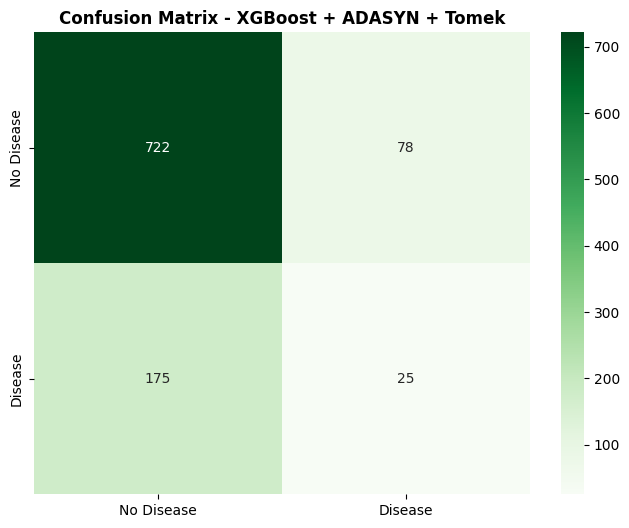

✓ Saved: XGBoost/models/XGBoost_adasyn_tomek_fold2.pkl
✓ Saved: XGBoost/models/adasyn_tomek_sampler_xgb.pkl
✓ Saved model


In [11]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import TomekLinks

print("-" * 30)
print('XGBoost + ADASYN + Tomek Links')
print("-" * 30)

# 1. Apply Pipeline
pipe_at = ImbPipeline([
    ('adasyn', ADASYN(random_state=42)),
    ('tomek', TomekLinks())
])
print("Resampling with ADASYN + Tomek...")
X_train_at, y_train_at = pipe_at.fit_resample(X_train, y_train.values.ravel())

print(f"Original size: {len(X_train)}")
print(f"After ADASYN+Tomek size: {len(X_train_at)}")
print("-" * 30)

# 2. Train Model
xgb_at = XGBClassifier(
    n_estimators=100, random_state=42,
    use_label_encoder=False, eval_metric='logloss'
)
xgb_at.fit(X_train_at, y_train_at)

# 3. Cross-Validation
cv_scores = []

# Cross-validation with ADASYN+Tomek and best-fold selection
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
best_model_xgb_adasyn_tomek = None
best_score_xgb_adasyn_tomek = -1.0
best_fold_idx_xgb_adasyn_tomek = -1

X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
y_train_np = y_train.values.ravel() if hasattr(y_train, 'values') else y_train

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_np, y_train_np)):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train_np[train_idx], y_train_np[val_idx]
    
    try:
        X_train_fold_at, y_train_fold_at = pipe_at.fit_resample(X_train_fold, y_train_fold)
    # Pipeline อาจจะคืนค่า X เป็น DF หรือ Array ขึ้นอยู่กับเวอร์ชั่น
    # เพื่อความปลอดภัย ใช้ .iloc ถ้าเป็น DF หรือ [] ถ้าเป็น Array
        if hasattr(X_train_fold_at, 'iloc'):
            X_train_fold_at_data = X_train_fold_at
        else:
            X_train_fold_at_data = X_train_fold_at
        
        xgb_fold = XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            eval_metric='logloss'
        )
        xgb_fold.fit(X_train_fold_at_data, y_train_fold_at)
        score = xgb_fold.score(X_val_fold, y_val_fold)
        cv_scores.append(score)
        
        # Track best fold
        if score > best_score_xgb_adasyn_tomek:
            best_model_xgb_adasyn_tomek = xgb_fold
            best_score_xgb_adasyn_tomek = score
            best_fold_idx_xgb_adasyn_tomek = fold + 1
    except ValueError as e:
        print(f"Warning in fold: {e}")
        continue
    
print("-" * 30)
print(f"Cross-Validation Scores (Total {len(cv_scores)} Folds):")
print("-" * 30)
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}  ({score*100:.2f}%)")

print("-" * 30)
print(f">> Average CV Accuracy: {np.mean(cv_scores):.4f}")
print("-" * 30)

# 4. Evaluation
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Use best fold model for test evaluation
print(f"✓ Selected best model from Fold {best_fold_idx_xgb_adasyn_tomek}")
print("-" * 30)

X_test_np = X_test.values if hasattr(X_test, 'values') else X_test

# Predictions using best-fold model
y_pred = best_model_xgb_adasyn_tomek.predict(X_test_np)
y_pred_proba = best_model_xgb_adasyn_tomek.predict_proba(X_test_np)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (ADASYN + Tomek) - Fold {}".format(best_fold_idx_xgb_adasyn_tomek))
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - XGBoost + ADASYN + Tomek', fontweight='bold')
plt.show()

# Save Results
xgb_adasyn_tomek_results = {
    'Model': 'XGBoost', 'Sampling': 'ADASYN+Tomek',
        'Best_Fold': best_fold_idx_xgb_adasyn_tomek,
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy, 'Precision': test_precision,
    'Recall': test_recall, 'F1_Score': test_f1, 'ROC_AUC': test_roc_auc
}

joblib.dump(xgb_at, 'XGBoost/models/XGB_adasyn_tomek.pkl')
joblib.dump(best_model_xgb_adasyn_tomek, 'XGBoost/models/XGBoost_adasyn_tomek_fold{}.pkl'.format(best_fold_idx_xgb_adasyn_tomek))
joblib.dump(pipe_at, 'XGBoost/models/adasyn_tomek_sampler_xgb.pkl')
print("✓ Saved: XGBoost/models/XGBoost_adasyn_tomek_fold{}.pkl".format(best_fold_idx_xgb_adasyn_tomek))
print("✓ Saved: XGBoost/models/adasyn_tomek_sampler_xgb.pkl")
print("✓ Saved model")

------------------------------
XGBoost + BorderlineSMOTE + Tomek Links
------------------------------
Resampling with BorderlineSMOTE + Tomek...


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Original size: 9000
After Borderline+Tomek size: 14272
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [21:29:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


------------------------------
Cross-Validation Scores (Total 5 Folds):
------------------------------
Fold 1: 0.6878  (68.78%)
Fold 2: 0.7061  (70.61%)
Fold 3: 0.6744  (67.44%)
Fold 4: 0.6928  (69.28%)
Fold 5: 0.6833  (68.33%)
------------------------------
>> Average CV Accuracy: 0.6889
------------------------------
------------------------------
>> Average CV Accuracy: 0.6889 (± 0.0105)
------------------------------
✓ Selected best model from Fold 2
------------------------------

TEST SET PERFORMANCE (Borderline + Tomek) - Fold 2
Accuracy:  0.6820
Precision: 0.2190
Recall:    0.2300
F1-Score:  0.2244
ROC-AUC:   0.5254


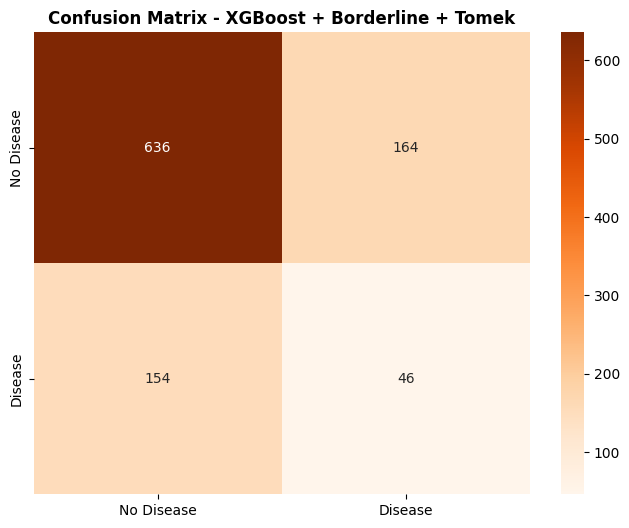

✓ Saved: XGBoost/models/XGBoost_borderline_tomek_fold2.pkl
✓ Saved: XGBoost/models/borderline_tomek_sampler_xgb.pkl
✓ Saved model


In [12]:
from imblearn.over_sampling import BorderlineSMOTE

print("-" * 30)
print('XGBoost + BorderlineSMOTE + Tomek Links')
print("-" * 30)

# 1. Apply Pipeline
pipe_bt = ImbPipeline([
    ('borderline', BorderlineSMOTE(random_state=42, kind='borderline-2')),
    ('tomek', TomekLinks())
])
print("Resampling with BorderlineSMOTE + Tomek...")
X_train_bt, y_train_bt = pipe_bt.fit_resample(X_train, y_train.values.ravel())

print(f"Original size: {len(X_train)}")
print(f"After Borderline+Tomek size: {len(X_train_bt)}")
print("-" * 30)

# 2. Train Model
xgb_bt = XGBClassifier(
    n_estimators=100, random_state=42,
    use_label_encoder=False, eval_metric='logloss'
)
xgb_bt.fit(X_train_bt, y_train_bt)

# 3. Cross-Validation
cv_scores = []

# Cross-validation with Borderline+Tomek and best-fold selection
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
best_model_xgb_borderline_tomek = None
best_score_xgb_borderline_tomek = -1.0
best_fold_idx_xgb_borderline_tomek = -1

X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
y_train_np = y_train.values.ravel() if hasattr(y_train, 'values') else y_train

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_np, y_train_np)):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train_np[train_idx], y_train_np[val_idx]
    
    try:
        X_train_fold_bt, y_train_fold_bt = pipe_bt.fit_resample(X_train_fold, y_train_fold)
    # Safe check for slicing
        if hasattr(X_train_fold_bt, 'iloc'):
            X_train_fold_bt_data = X_train_fold_bt
        else:
            X_train_fold_bt_data = X_train_fold_bt
        
        xgb_fold = XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            eval_metric='logloss'
        )
        xgb_fold.fit(X_train_fold_bt_data, y_train_fold_bt)
        score = xgb_fold.score(X_val_fold, y_val_fold)
        cv_scores.append(score)
        
        # Track best fold
        if score > best_score_xgb_borderline_tomek:
            best_model_xgb_borderline_tomek = xgb_fold
            best_score_xgb_borderline_tomek = score
            best_fold_idx_xgb_borderline_tomek = fold + 1
    except ValueError as e:
        print(f"Warning in fold: {e}")
        continue
    
print("-" * 30)
print(f"Cross-Validation Scores (Total {len(cv_scores)} Folds):")
print("-" * 30)
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}  ({score*100:.2f}%)")

print("-" * 30)
print(f">> Average CV Accuracy: {np.mean(cv_scores):.4f}")
print("-" * 30)

# 4. Evaluation
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Use best fold model for test evaluation
print(f"✓ Selected best model from Fold {best_fold_idx_xgb_borderline_tomek}")
print("-" * 30)

X_test_np = X_test.values if hasattr(X_test, 'values') else X_test

# Predictions using best-fold model
y_pred = best_model_xgb_borderline_tomek.predict(X_test_np)
y_pred_proba = best_model_xgb_borderline_tomek.predict_proba(X_test_np)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (Borderline + Tomek) - Fold {}".format(best_fold_idx_xgb_borderline_tomek))
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - XGBoost + Borderline + Tomek', fontweight='bold')
plt.show()

# Save Results
xgb_borderline_tomek_results = {
    'Model': 'XGBoost', 'Sampling': 'Borderline+Tomek',
        'Best_Fold': best_fold_idx_xgb_borderline_tomek,
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy, 'Precision': test_precision,
    'Recall': test_recall, 'F1_Score': test_f1, 'ROC_AUC': test_roc_auc
}

joblib.dump(xgb_bt, 'XGBoost/models/XGB_borderline_tomek.pkl')
joblib.dump(best_model_xgb_borderline_tomek, 'XGBoost/models/XGBoost_borderline_tomek_fold{}.pkl'.format(best_fold_idx_xgb_borderline_tomek))
joblib.dump(pipe_bt, 'XGBoost/models/borderline_tomek_sampler_xgb.pkl')
print("✓ Saved: XGBoost/models/XGBoost_borderline_tomek_fold{}.pkl".format(best_fold_idx_xgb_borderline_tomek))
print("✓ Saved: XGBoost/models/borderline_tomek_sampler_xgb.pkl")
print("✓ Saved model")


XGBOOST - COMPREHENSIVE SUMMARY
  Model           Sampling  Best_Fold  CV_Accuracy   CV_Std  Test_Accuracy  Precision  Recall  F1_Score  ROC_AUC
XGBoost    None (Baseline)          2     0.797444 0.002183          0.798   0.250000   0.005  0.009804 0.497025
XGBoost              SMOTE          2     0.728778 0.010895          0.749   0.296000   0.185  0.227692 0.548037
XGBoost             ADASYN          2     0.744667 0.004927          0.737   0.221239   0.125  0.159744 0.534956
XGBoost RandomUnderSampler          2     0.503333 0.010915          0.486   0.198077   0.515  0.286111 0.487187
XGBoost   ClusterCentroids          1     0.341333 0.014396          0.350   0.200798   0.755  0.317227 0.502613
XGBoost         SMOTETomek          5     0.731000 0.008191          0.732   0.230159   0.145  0.177914 0.514281
XGBoost           SMOTEENN          4     0.505778 0.011513          0.508   0.211462   0.535  0.303116 0.523481
XGBoost           NearMiss          1     0.369444 0.004431    

/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_14500/3259299714.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xgb_df['Sampling'], rotation=45, ha='right')
/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_14500/3259299714.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xgb_df['Sampling'], rotation=45, ha='right')
/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_14500/3259299714.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xgb_df['Sampling'], rotation=45, ha='right')
/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_14500/3259299714.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. a

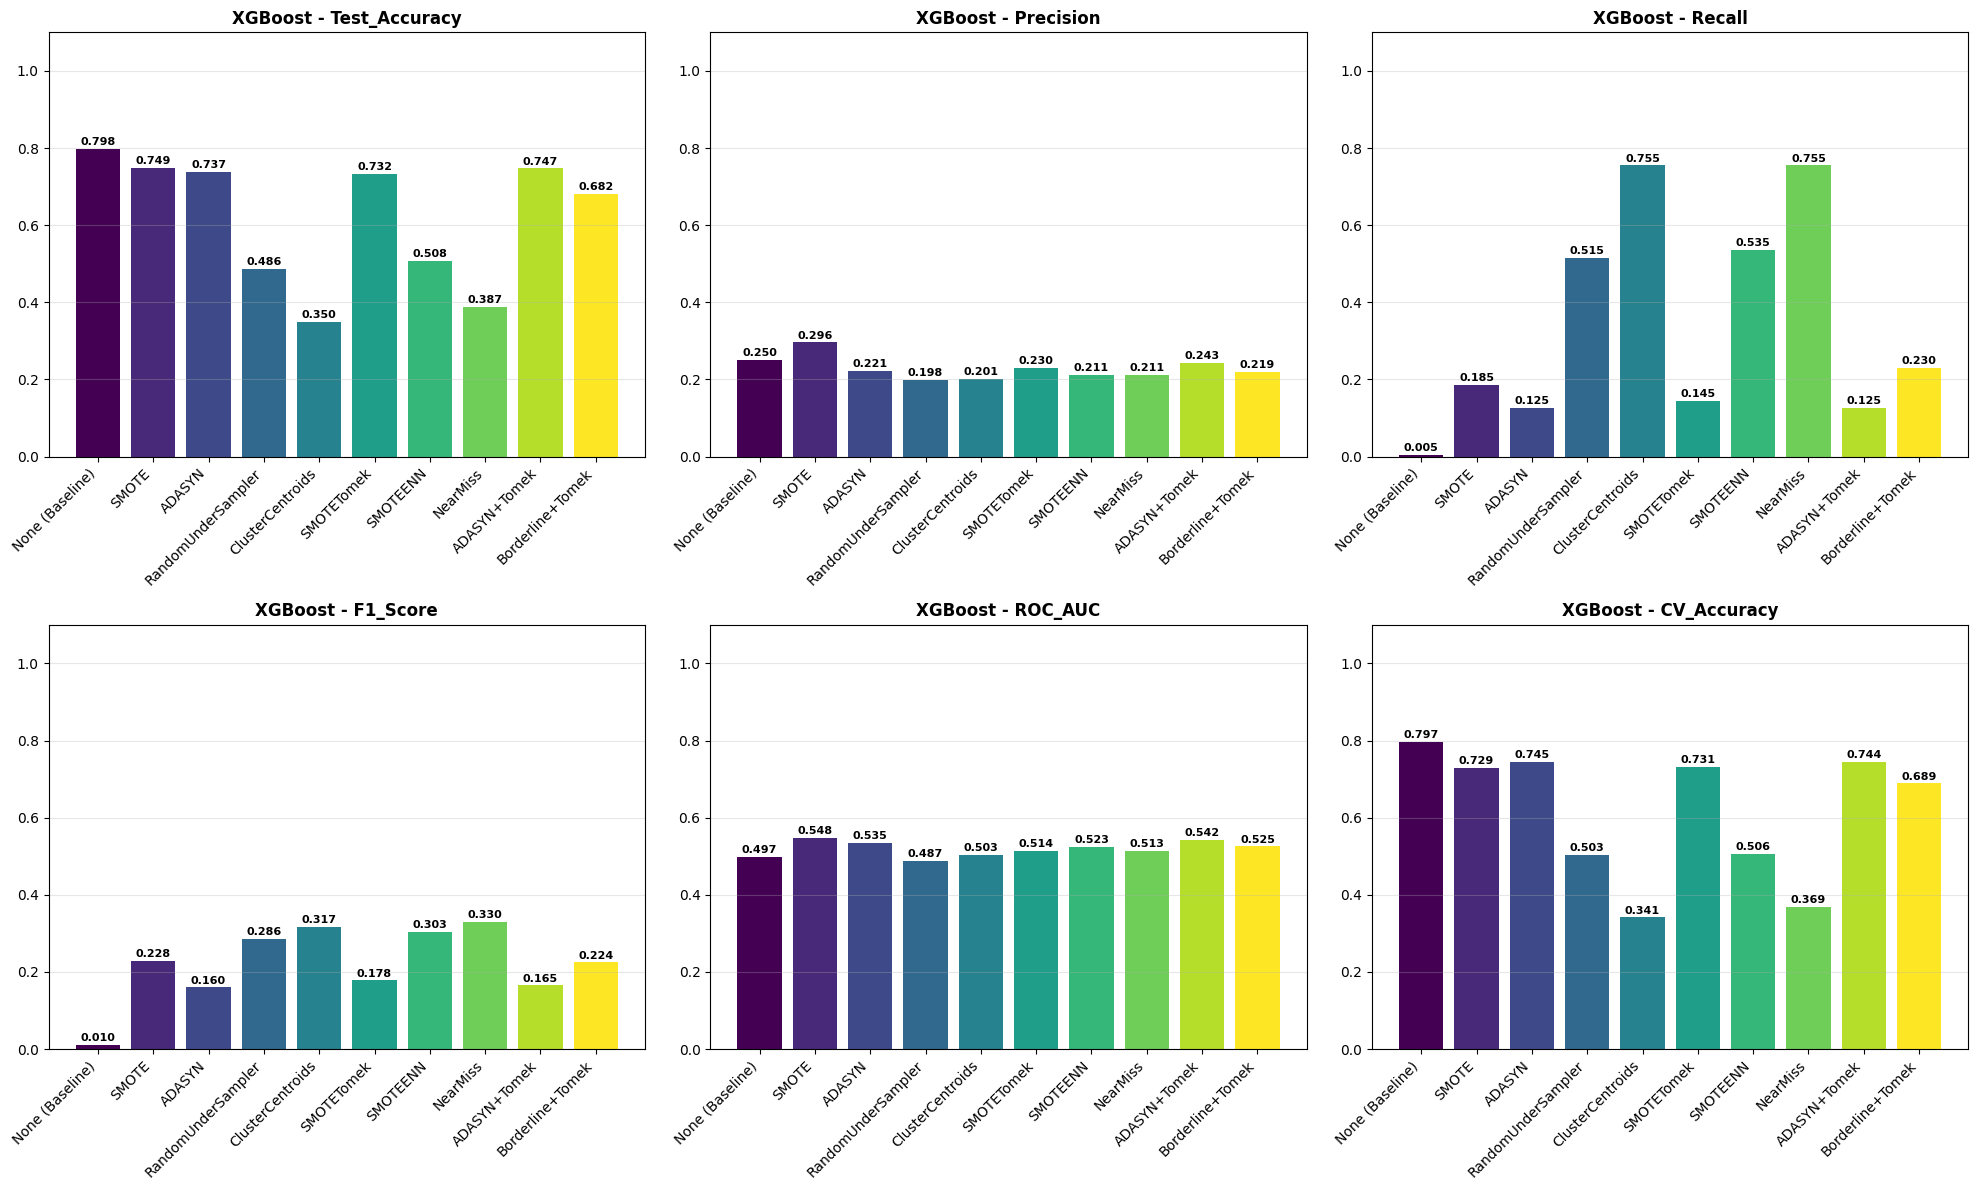


🏆 BEST XGBOOST MODEL
Best by F1-Score: NearMiss (0.3301)


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# 1. รวบรวมผลลัพธ์ (เช็คชื่อตัวแปรเก่าให้ครบนะครับ)
xgb_all_results = [
    xgb_baseline_results,
    xgb_smote_results,
    xgb_adasyn_results,
    xgb_rus_results,
    xgb_cc_results,
    xgb_smote_tomek_results,
    xgb_smote_enn_results,
    xgb_nearmiss_results,
    xgb_adasyn_tomek_results,
    xgb_borderline_tomek_results
]

# 2. สร้าง DataFrame
xgb_df = pd.DataFrame(xgb_all_results)

print("\n" + "=" * 90)
print("XGBOOST - COMPREHENSIVE SUMMARY")
print("=" * 90)
print(xgb_df.to_string(index=False))

# 3. Save CSV
os.makedirs('XGBoost/models', exist_ok=True)
xgb_df.to_csv('XGBoost/models/xgb_summary.csv', index=False)
print("✓ Saved summary CSV")

# 4. Visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
metrics = ['Test_Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC', 'CV_Accuracy']
colors = plt.cm.viridis(np.linspace(0, 1, len(xgb_df)))

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    if metric in xgb_df.columns:
        bars = ax.bar(xgb_df['Sampling'], xgb_df[metric], color=colors)
        ax.set_title(f'XGBoost - {metric}', fontsize=12, fontweight='bold')
        ax.set_xticklabels(xgb_df['Sampling'], rotation=45, ha='right')
        ax.set_ylim([0, 1.1])
        ax.grid(axis='y', alpha=0.3)
        
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01, 
                    f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('XGBoost/models/xgb_comparison_plot.png', dpi=300)
plt.show()

# 5. Best Model Recommendation
print("\n" + "=" * 90)
print("🏆 BEST XGBOOST MODEL")
print("=" * 90)
best_f1_idx = xgb_df['F1_Score'].idxmax()
print(f"Best by F1-Score: {xgb_df.loc[best_f1_idx, 'Sampling']} ({xgb_df.loc[best_f1_idx, 'F1_Score']:.4f})")